In [3]:
import pandas as pd

url = r"C:\Users\DELL\Downloads\Extracted_permssion_updated.csv"
df = pd.read_csv(url)

print(df.head())


                        pkgname    App categore   Downloads  \
0                      Abc news  News & Magazines       5 M   
1         Acorns: Save & Invest           Finance      10 M   
2                    AliExpress          Shopping     500 M   
3  Allstate Benefits MyBenefits          Business      10 K   
4                        Amazon          Shopping     500 M   

   ACCESS_CHECKIN_PROPERTIES  ACCESS_COARSE_LOCATION  ACCESS_FINE_LOCATION  \
0                          0                       0                     0   
1                          0                       1                     1   
2                          0                       1                     1   
3                          0                       0                     0   
4                          0                       1                     0   

   ACCESS_LOCATION_EXTRA_COMMANDS  ACCESS_NETWORK_STATE  \
0                               0                     1   
1                               0 

                        pkgname    App categore   Downloads  \
0                      Abc news  News & Magazines       5 M   
1         Acorns: Save & Invest           Finance      10 M   
2                    AliExpress          Shopping     500 M   
3  Allstate Benefits MyBenefits          Business      10 K   
4                        Amazon          Shopping     500 M   

   ACCESS_CHECKIN_PROPERTIES  ACCESS_COARSE_LOCATION  ACCESS_FINE_LOCATION  \
0                          0                       0                     0   
1                          0                       1                     1   
2                          0                       1                     1   
3                          0                       0                     0   
4                          0                       1                     0   

   ACCESS_LOCATION_EXTRA_COMMANDS  ACCESS_NETWORK_STATE  \
0                               0                     1   
1                               0 

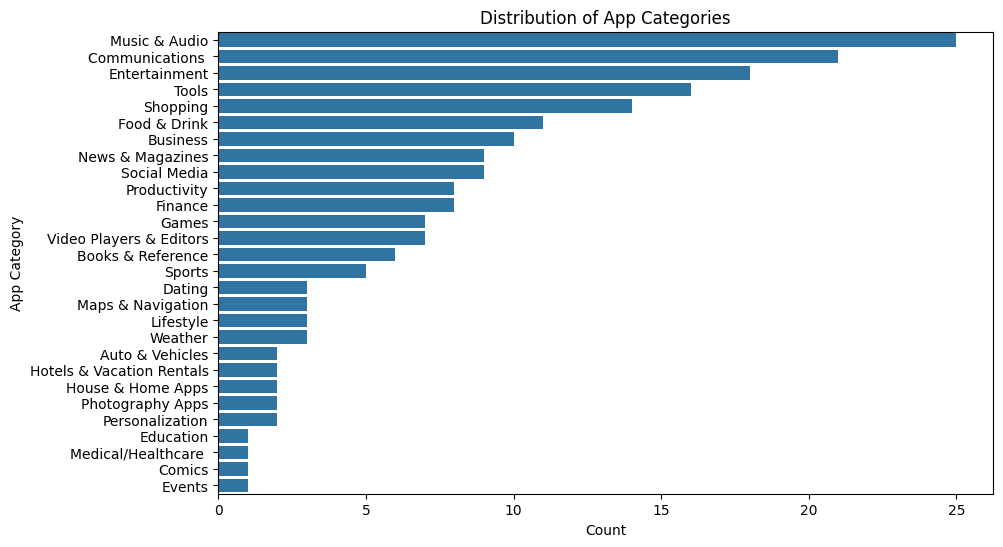

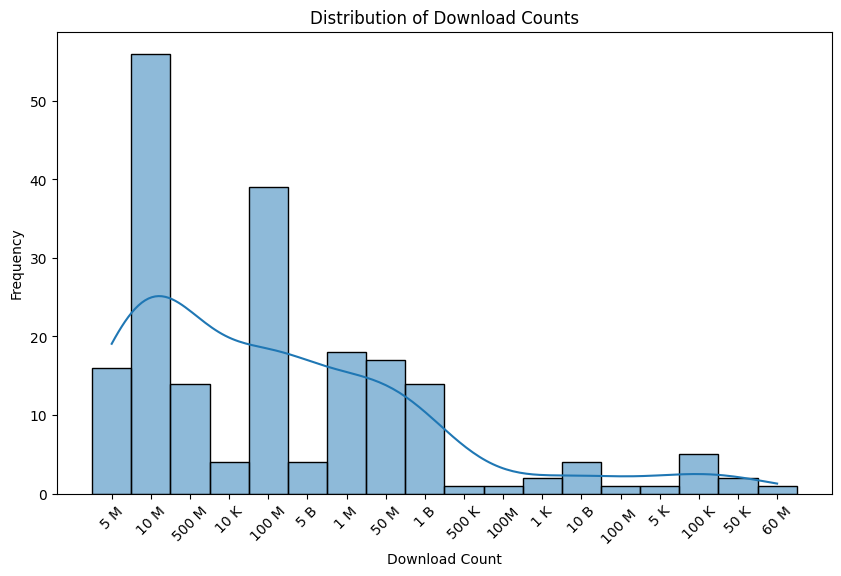

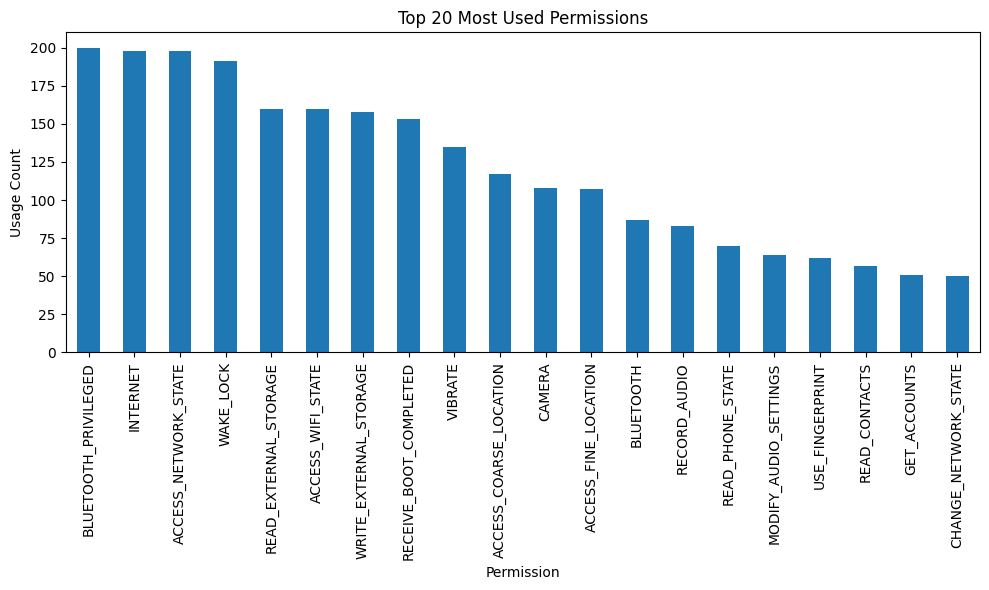

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# loading dataset
url = r"C:\Users\DELL\Downloads\Extracted_permssion_updated.csv"
df = pd.read_csv(url)

print(df.head())
df.shape
df.info()





# Visualize distribution of app categories
plt.figure(figsize=(10, 6))
sns.countplot(y='App categore  ', data=df, order=df['App categore  '].value_counts().index)
plt.title('Distribution of App Categories')
plt.xlabel('Count')
plt.ylabel('App Category')
plt.show()

# Visualize distribution of download counts
# Define the custom order for x-axis labels
custom_order = ['1 K', '5 K', '10 K', '50 K', '100 K', '500 K', '1 M', '5 M', 
               '10 M', '50 M', '60 M', '100 M', '500 M', '1 B', '5 B', '10 B']
plt.figure(figsize=(10, 6))
sns.histplot(df['Downloads'], bins=16, kde=True)
plt.title('Distribution of Download Counts')
plt.xlabel('Download Count')
plt.ylabel('Frequency')
plt.xticks(rotation=45)  
plt.show()

# Visualize permission usage patterns
permission_cols = df.columns[3:]  
df[permission_cols] = df[permission_cols].astype(bool)
permission_usage = df[permission_cols].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
permission_usage.head(20).plot(kind='bar')
plt.title('Top 20 Most Used Permissions')
plt.xlabel('Permission')
plt.ylabel('Usage Count')
plt.xticks(rotation=90) 
plt.tight_layout()  
plt.show()

Step 2: Feature Engineering

Selecting Relevant Features

In [6]:
# Filter data for 'Communications' category
communications_data = df[df['App categore  '] == 'Communications ']

# Extracting relevant features (permissions)
X = communications_data[permission_cols].values

# Target variable
y = np.ones(len(X))  # All instances belong to 'Communications' category

# Filter data for other categories
other_data = df[df['App categore  '] != 'Communications'].sample(len(communications_data))

# Extracting relevant features for other categories
X_other = other_data[permission_cols].values

# Target variable for other categories
y_other = np.zeros(len(X_other))  # Instances don't belong to 'Communications' category

# Combining data
X = np.concatenate((X, X_other), axis=0)
y = np.concatenate((y, y_other), axis=0)

Dimensionality Reduction:

In [7]:
from sklearn.decomposition import PCA

# Perform PCA for dimensionality reduction
pca = PCA(n_components=40)
X_pca = pca.fit_transform(X)

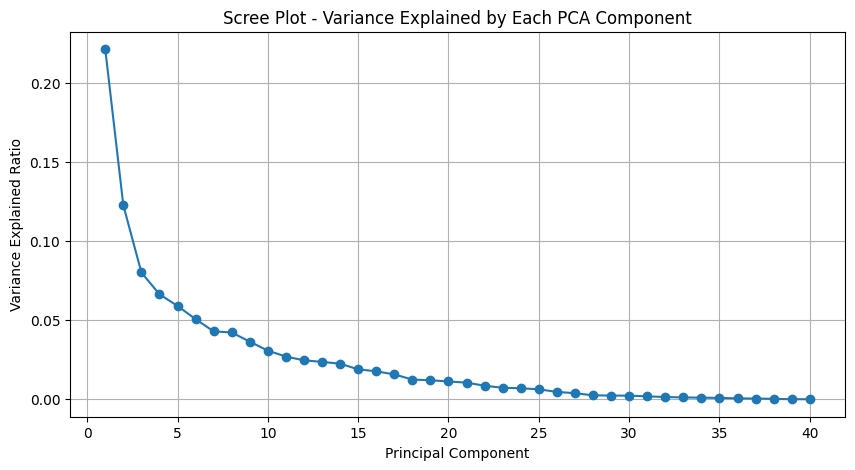

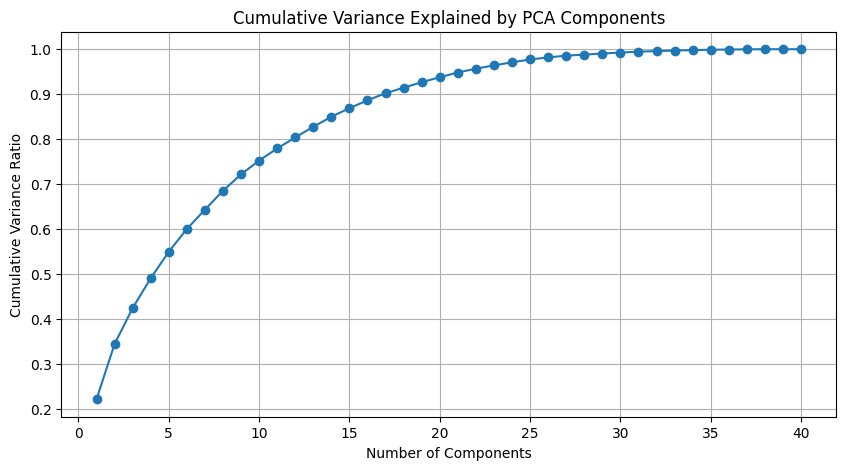

In [12]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Perform PCA
pca = PCA(n_components=40)
X_pca = pca.fit_transform(X)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# --- Plot 1: Variance Explained per Component ---
plt.figure(figsize=(10, 5))
plt.plot(range(1, 41), explained_variance, marker='o')
plt.title("Scree Plot - Variance Explained by Each PCA Component")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained Ratio")
plt.grid(True)
plt.show()

# --- Plot 2: Cumulative Variance Explained ---
plt.figure(figsize=(10, 5))
plt.plot(range(1, 41), cumulative_variance, marker='o')
plt.title("Cumulative Variance Explained by PCA Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Ratio")
plt.grid(True)
plt.show()


Step 3: Model development

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss, roc_curve

# Splitting the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Initialize logistic regression model
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

# Predictions on test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # Probability estimates for the positive class

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, log_loss, classification_report
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

# Initialize logistic regression
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Display Outputs
print("🔹 Logistic Regression Evaluation Results\n")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Log Loss:", log_loss(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


🔹 Logistic Regression Evaluation Results

Accuracy: 0.5555555555555556
Precision: 0.5
Recall: 0.5
F1 Score: 0.5
ROC-AUC: 0.7
Log Loss: 0.7747807103404437

Classification Report:

              precision    recall  f1-score   support

         0.0       0.60      0.60      0.60         5
         1.0       0.50      0.50      0.50         4

    accuracy                           0.56         9
   macro avg       0.55      0.55      0.55         9
weighted avg       0.56      0.56      0.56         9



Step 4: Model evaluation

Accuracy: 0.5555555555555556
Precision: 0.5
Recall: 0.5
F1-score: 0.5
ROC AUC Score: 0.7
Log Loss: 0.7747807103404437


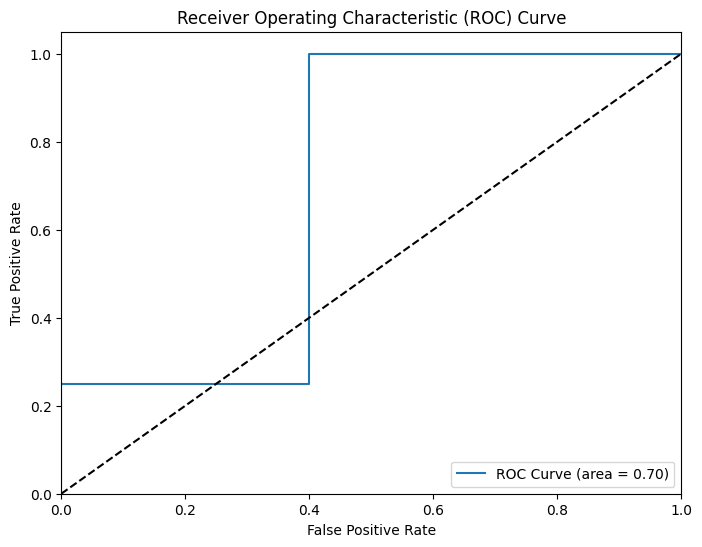

In [10]:
# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
logloss = log_loss(y_test, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC AUC Score:", roc_auc)
print("Log Loss:", logloss)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC Curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()





Step 5: Analysis of the coefficients of the logistic regression model

Top 20 important features for predicting 'Communications' category:
BIND_CHOOSER_TARGET_SERVICE : -1.2515055001570836
BIND_ACCESSIBILITY_SERVICE : 0.9295689323974531
ACCESS_LOCATION_EXTRA_COMMANDS : 0.8471288080474433
ADD_VOICEMAIL : 0.641061768300254
ACCESS_WIFI_STATE : 0.6149782053350098
ACCOUNT_MANAGER : -0.5823126784225011
BATTERY_STATS : 0.5240292830126867
ACCESS_CHECKIN_PROPERTIES : 0.5095355178459325
BIND_VPN_SERVICE : -0.49564949894350674
ACCESS_NOTIFICATION_POLICY : -0.4905757203195216
ACCESS_NETWORK_STATE : -0.479439008294323
BIND_SCREENING_SERVICE : -0.3436707687177467
BIND_TV_INPUT : 0.330118350779109
BIND_CONDITION_PROVIDER_SERVICE : 0.3112077629560476
BIND_INPUT_METHOD : -0.30908288810323387
BIND_REMOTEVIEWS : -0.30427001403682064
BIND_INCALL_SERVICE : -0.2998301713134769
BIND_APPWIDGET : -0.2556488703220053
BIND_TEXT_SERVICE : 0.2525494082119987
BLUETOOTH : 0.24191120408060504